# Phase 7 — Alpha Dynamics, Cross-Film Validation & Visualization

**Goal:** Find healthy alpha values for all channels using dynamics-based criteria,
validate across multiple films, and visualize the S-U causal chain.

**Sections:**
1. R-07b: Cross-output consistency on real films (all channels)
2. U-01–U-04: Uncertainty diagnostics
3. Alpha sweep with hierarchical constraint
4. Cross-film alpha validation
5. Visualization: time series, zoomed view, scatter plots

Requires real film pipeline outputs (df1 + df2 parquet files).

In [2]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr

sys.path.insert(0, '/home/tamires/projects/rpp-aevans-ab/tamires/DecomposingMovies')

import cinematic_surprise.config as cfg
from cinematic_surprise.config import ALPHA, CHANNELS, EMA_EPSILON
from cinematic_surprise.uncertainty_and_surprise.estimator import OnlineGaussianEstimator

%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 4)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

print(f"Channels: {CHANNELS}")
print(f"Current alphas: {ALPHA}")
print("\nSetup complete.")

I0000 00:00:1774401071.839981 1590701 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774401071.879704 1590701 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774401072.883358 1590701 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Channels: ['L1', 'L2', 'L3', 'L4', 'semantic', 'emotion', 'faces', 'motion', 'audio_mel', 'audio_spec', 'audio_onset', 'narrative']
Current alphas: {'L1': 0.1, 'L2': 0.1, 'L3': 0.05, 'L4': 0.05, 'semantic': 0.03, 'emotion': 0.03, 'faces': 0.05, 'motion': 0.1, 'audio_mel': 0.05, 'audio_spec': 0.05, 'audio_onset': 0.1, 'narrative': 0.01}

Setup complete.


In [13]:
# ── Load all available film outputs ──
OUTPUTS_DIR = Path("/home/tamires/projects/rpp-aevans-ab/tamires/DecomposingMovies/outputs")

films = {}
for df1_file in sorted(OUTPUTS_DIR.glob("*_surprise_uncertainty.parquet")):
    name = df1_file.stem.replace("_surprise_uncertainty", "")
    df2_file = df1_file.parent / f"{name}_features.parquet"
    if df2_file.exists():
        films[name] = {
            "df1": pd.read_parquet(df1_file),
            "df2": pd.read_parquet(df2_file),
        }
        print(f"  {name}: df1={films[name]['df1'].shape} df2={films[name]['df2'].shape}")

print(f"\nTotal films: {len(films)}")

  12_years_a_slave: df1=(7717, 48) df2=(7717, 4900)
  500_days_of_summer: df1=(5472, 48) df2=(5472, 4900)
  back_to_the_future: df1=(6676, 48) df2=(6676, 4900)
  citizenfour: df1=(6798, 48) df2=(6798, 4900)
  little_miss_sunshine: df1=(5902, 48) df2=(5902, 4900)
  pulp_fiction: df1=(8883, 48) df2=(8883, 4900)
  split: df1=(6741, 48) df2=(6741, 4900)
  the_prestige: df1=(7516, 48) df2=(7516, 4900)
  the_shawshank_redemption: df1=(8183, 48) df2=(8183, 4900)
  the_usual_suspects: df1=(6103, 48) df2=(6103, 4900)

Total films: 10


---
# 1. R-07b: Cross-Output Consistency on Real Films

In [14]:
for film_name, data in films.items():
    df1, df2 = data["df1"], data["df2"]
    print(f"\n{'='*70}")
    print(f"{film_name} ({len(df1)} seconds)")
    print(f"{'Channel':<15} {'r(S,Δf)':>9} {'p':>10} {'Status'}")
    print("-" * 50)
    offset = 0
    for ch in cfg.FEATURE_CHANNEL_ORDER:
        d = cfg.FEATURE_DIMS[ch]
        s_col = f'surprise_{ch}'
        if s_col not in df1.columns or df1[s_col].isna().all():
            print(f"  {ch:<15} {'SKIP':>9}")
            offset += d
            continue
        feats = df2.iloc[:, offset:offset+d].values
        deltas = np.linalg.norm(np.diff(feats, axis=0), axis=1)
        surprise = df1[s_col].values[1:]
        valid = ~(np.isnan(surprise) | np.isnan(deltas))
        if valid.sum() > 30 and deltas[valid].std() > 1e-9 and surprise[valid].std() > 1e-9:
            r, p = spearmanr(surprise[valid], deltas[valid])
            status = '✓' if r > 0.3 else ('~ weak' if r > 0.1 else '✗')
            print(f"  {ch:<15} {r:>+9.3f} {p:>10.2e} {status}")
        else:
            print(f"  {ch:<15} {'N/A':>9} {'':>10} (low variance)")
        offset += d


12_years_a_slave (7717 seconds)
Channel           r(S,Δf)          p Status
--------------------------------------------------
  L1                 +0.713   0.00e+00 ✓
  L2                 +0.640   0.00e+00 ✓
  L3                 +0.703   0.00e+00 ✓
  L4                 +0.392  1.12e-281 ✓
  semantic           +0.605   0.00e+00 ✓
  emotion            +0.187   1.93e-61 ~ weak
  faces              +0.562   0.00e+00 ✓
  motion             +0.309  1.11e-170 ✓
  audio_mel          +0.199   1.56e-69 ~ weak
  audio_spec         +0.273  3.96e-132 ~ weak
  audio_onset        +0.294  6.36e-154 ~ weak
  narrative          +0.528   0.00e+00 ✓

500_days_of_summer (5472 seconds)
Channel           r(S,Δf)          p Status
--------------------------------------------------
  L1                 +0.562   0.00e+00 ✓
  L2                 +0.466  1.23e-293 ✓
  L3                 +0.592   0.00e+00 ✓
  L4                 +0.372  2.91e-179 ✓
  semantic           +0.547   0.00e+00 ✓
  emotion            +0.1

---
# 2. Uncertainty Diagnostics (U-01 to U-04)

## U-01: Uncertainty Variability Per Channel

In [15]:
for film_name, data in films.items():
    df1 = data["df1"]
    print(f"\n{'='*70}")
    print(f"{film_name}")
    print(f"{'Channel':<15} {'alpha':<7} {'U_mean':>10} {'U_std':>10} {'U_cv':>8} {'S_mean':>10} {'S_std':>10} {'Diag'}")
    print("-" * 90)
    for ch in CHANNELS:
        u_col, s_col = f'uncertainty_{ch}', f'surprise_{ch}'
        if u_col not in df1.columns or df1[u_col].isna().all():
            continue
        u, s = df1[u_col].dropna(), df1[s_col].dropna()
        u_cv = u.std() / abs(u.mean()) if abs(u.mean()) > 1e-9 else 0
        diag = '⚠ CONST' if u_cv < 0.05 else ('~ low' if u_cv < 0.15 else '✓ good')
        print(f"  {ch:<15} {ALPHA.get(ch,'?'):<7} {u.mean():>10.4f} {u.std():>10.4f} {u_cv:>8.4f} {s.mean():>10.4f} {s.std():>10.4f} {diag}")


12_years_a_slave
Channel         alpha       U_mean      U_std     U_cv     S_mean      S_std Diag
------------------------------------------------------------------------------------------
  L1              0.1       -12.2176     1.1380   0.0931     0.0810     0.5604 ~ low
  L2              0.1       -11.9633     1.0264   0.0858     0.0448     0.2544 ~ low
  L3              0.05      -11.1761     0.8335   0.0746     0.0047     0.0174 ~ low
  L4              0.05       -5.4582     1.2495   0.2289     0.0255     0.4342 ✓ good
  semantic        0.03       -9.8081     0.7233   0.0737     0.0012     0.0031 ~ low
  emotion         0.03       -5.1462     0.7454   0.1449     0.0108     0.2316 ~ low
  faces           0.05       -0.7273     2.4702   3.3962     0.4115    18.6776 ✓ good
  motion          0.1       -11.3377     1.3741   0.1212     0.8161     4.9883 ~ low
  audio_mel       0.05        3.6297     0.6263   0.1726     0.0057     0.1899 ✓ good
  audio_spec      0.05       -7.8809     

## U-02: Raw Feature Variance vs EMA Uncertainty

In [16]:
window = 30
for film_name, data in films.items():
    df1, df2 = data["df1"], data["df2"]
    print(f"\n{film_name}")
    print(f"{'Channel':<15} {'Raw CV':>10} {'EMA U CV':>10} {'Diagnostic'}")
    print("-" * 55)
    offset = 0
    for ch in cfg.FEATURE_CHANNEL_ORDER:
        d = cfg.FEATURE_DIMS[ch]
        u_col = f'uncertainty_{ch}'
        if u_col not in df1.columns or df1[u_col].isna().all():
            offset += d
            continue
        feats = df2.iloc[:, offset:offset+d].values
        rstds = [feats[max(0,t-window):t].std(axis=0).mean() for t in range(window, len(feats))]
        rstds = np.array(rstds)
        raw_cv = rstds.std() / rstds.mean() if rstds.mean() > 1e-9 else 0
        u = df1[u_col].dropna()
        ema_cv = u.std() / abs(u.mean()) if abs(u.mean()) > 1e-9 else 0
        if raw_cv > 0.1 and ema_cv < 0.05:
            diag = '⚠ OVERSMOOTH'
        elif raw_cv < 0.05 and ema_cv < 0.05:
            diag = '— genuinely constant'
        else:
            diag = '✓ both vary'
        print(f"  {ch:<15} {raw_cv:>10.4f} {ema_cv:>10.4f} {diag}")
        offset += d


12_years_a_slave
Channel             Raw CV   EMA U CV Diagnostic
-------------------------------------------------------
  L1                  0.5201     0.0931 ✓ both vary
  L2                  0.4439     0.0858 ✓ both vary
  L3                  0.3268     0.0746 ✓ both vary
  L4                  0.2886     0.2289 ✓ both vary
  semantic            0.2351     0.0737 ✓ both vary
  emotion             0.2611     0.1449 ✓ both vary
  faces               0.5721     3.3962 ✓ both vary
  motion              0.5101     0.1212 ✓ both vary
  audio_mel           0.3720     0.1726 ✓ both vary
  audio_spec          0.3494     0.1086 ✓ both vary
  audio_onset         0.4610     0.7363 ✓ both vary
  narrative           0.6666     0.1879 ✓ both vary

500_days_of_summer
Channel             Raw CV   EMA U CV Diagnostic
-------------------------------------------------------
  L1                  0.4689     0.0941 ✓ both vary
  L2                  0.3990     0.0850 ✓ both vary
  L3                  0.

## U-03: Surprise-Uncertainty Correlation (Contemporaneous + Lagged)

In [17]:
for film_name, data in films.items():
    df1 = data["df1"]
    print(f"\n{film_name}")
    print(f"{'Channel':<15} {'r(S,U)':>8} {'r(S,U+1)':>9} {'Contemp':>12} {'Lag':>20}")
    print("-" * 70)
    for ch in CHANNELS:
        s_col, u_col = f'surprise_{ch}', f'uncertainty_{ch}'
        if s_col not in df1.columns or df1[s_col].isna().all():
            continue
        s, u = df1[s_col].dropna().values, df1[u_col].dropna().values
        n = min(len(s), len(u))
        if n < 30 or s[:n].std() < 1e-9 or u[:n].std() < 1e-9:
            print(f"  {ch:<15} {'N/A':>8} {'N/A':>9} {'insuff var':>12}")
            continue
        r_c, _ = spearmanr(s[:n], u[:n])
        r_l, _ = spearmanr(s[:n-1], u[1:n])
        ic = '✓ indep' if abs(r_c)<0.2 else ('~ weak' if abs(r_c)<0.5 else '⚠ coupled')
        il = '⚠ none' if r_l<0.1 else ('✓ healthy' if r_l<0.5 else ('~ strong' if r_l<0.8 else '⚠ dominated'))
        print(f"  {ch:<15} {r_c:>+8.3f} {r_l:>+9.3f} {ic:>12} {il:>20}")


12_years_a_slave
Channel           r(S,U)  r(S,U+1)      Contemp                  Lag
----------------------------------------------------------------------
  L1                +0.646    +0.770    ⚠ coupled             ~ strong
  L2                +0.593    +0.753    ⚠ coupled             ~ strong
  L3                +0.494    +0.710       ~ weak             ~ strong
  L4                +0.178    +0.411      ✓ indep            ✓ healthy
  semantic          +0.223    +0.499       ~ weak            ✓ healthy
  emotion           +0.086    +0.130      ✓ indep            ✓ healthy
  faces             +0.429    +0.467       ~ weak            ✓ healthy
  motion            +0.623    +0.713    ⚠ coupled             ~ strong
  audio_mel         -0.093    -0.022      ✓ indep               ⚠ none
  audio_spec        +0.089    +0.167      ✓ indep            ✓ healthy
  audio_onset       -0.034    +0.100      ✓ indep               ⚠ none
  narrative         +0.055    +0.067      ✓ indep            

## U-04: Narrative L2-Normalization in df2

In [18]:
for film_name, data in films.items():
    df2 = data["df2"]
    offset = 0
    for ch in cfg.FEATURE_CHANNEL_ORDER:
        d = cfg.FEATURE_DIMS[ch]
        if ch == 'narrative':
            narr = df2.iloc[:, offset:offset+d].values
            norms = np.linalg.norm(narr, axis=1)
            nz = norms[norms > 0.01]
            print(f"{film_name}: speech={len(nz)} silence={len(norms)-len(nz)} "
                  f"speech_norm_mean={nz.mean():.4f}" if len(nz) > 0 else f"{film_name}: no speech")
            if len(nz) > 0:
                ok = abs(nz.mean() - 1.0) < 0.05
                print(f"  Norm ≈ 1.0? {ok}  {'✓' if ok else '✗'}")
        offset += d

12_years_a_slave: speech=7656 silence=61 speech_norm_mean=1.0000
  Norm ≈ 1.0? True  ✓
500_days_of_summer: speech=5411 silence=61 speech_norm_mean=1.0000
  Norm ≈ 1.0? True  ✓
back_to_the_future: speech=6590 silence=86 speech_norm_mean=1.0000
  Norm ≈ 1.0? True  ✓
citizenfour: speech=6753 silence=45 speech_norm_mean=1.0000
  Norm ≈ 1.0? True  ✓
little_miss_sunshine: speech=5857 silence=45 speech_norm_mean=1.0000
  Norm ≈ 1.0? True  ✓
pulp_fiction: speech=8856 silence=27 speech_norm_mean=1.0000
  Norm ≈ 1.0? True  ✓
split: speech=6692 silence=49 speech_norm_mean=1.0000
  Norm ≈ 1.0? True  ✓
the_prestige: speech=7450 silence=66 speech_norm_mean=1.0000
  Norm ≈ 1.0? True  ✓
the_shawshank_redemption: speech=8078 silence=105 speech_norm_mean=1.0000
  Norm ≈ 1.0? True  ✓
the_usual_suspects: speech=5899 silence=204 speech_norm_mean=1.0000
  Norm ≈ 1.0? True  ✓


---
# 3. Alpha Sweep with Hierarchical Constraint

In [19]:
def run_ema_with_alpha(features, alpha_val, epsilon=EMA_EPSILON):
    est = OnlineGaussianEstimator(alpha={"ch": alpha_val}, epsilon=epsilon)
    T = features.shape[0]
    surprises = np.zeros(T)
    uncertainties = np.zeros(T)
    for t in range(T):
        s, u = est.update(features[t], "ch")
        surprises[t] = s
        uncertainties[t] = u
    return surprises, uncertainties

def compute_su_correlations(surprises, uncertainties, skip=10):
    s, u = surprises[skip:], uncertainties[skip:]
    if len(s) < 30 or s.std() < 1e-12 or u.std() < 1e-12:
        return np.nan, np.nan
    r_c, _ = spearmanr(s, u)
    r_l, _ = spearmanr(s[:-1], u[1:])
    return r_c, r_l

# Hierarchical constraint: expected ordering of adaptation speed
# Faster (higher alpha) → Slower (lower alpha)
HIERARCHY = {
    # Group 1: fast adapting (V1, V2, motion)
    "L1": 1, "L2": 1, "motion": 1,
    # Group 2: medium (LOC, IT, faces, audio)
    "L3": 2, "L4": 2, "faces": 2, "audio_mel": 2, "audio_spec": 2,
    # Group 3: fast transient
    "audio_onset": 1,
    # Group 4: slow (semantic, emotion)
    "semantic": 3, "emotion": 3,
    # Group 5: very slow (narrative)
    "narrative": 4,
}

alphas_to_test = [0.005, 0.01, 0.02, 0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.30]

print("Alpha sweep configuration:")
print(f"  Alphas: {alphas_to_test}")
print(f"  Hierarchy groups: {set(HIERARCHY.values())} (1=fastest, 4=slowest)")
print(f"  Criterion: r(S,U) < 0.3 AND r(S,U+1) ∈ [0.2, 0.6]")
print("  Constraint: higher group number → alpha must be ≤ lower group")

Alpha sweep configuration:
  Alphas: [0.005, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.3]
  Hierarchy groups: {1, 2, 3, 4} (1=fastest, 4=slowest)
  Criterion: r(S,U) < 0.3 AND r(S,U+1) ∈ [0.2, 0.6]
  Constraint: higher group number → alpha must be ≤ lower group


In [20]:
# Run sweep on first film
sweep_film = list(films.keys())[0]
df2_sweep = films[sweep_film]["df2"]
print(f"Sweeping on: {sweep_film}")
print()

sweep_results = {}
offset = 0
for ch in cfg.FEATURE_CHANNEL_ORDER:
    d = cfg.FEATURE_DIMS[ch]
    feats = df2_sweep.iloc[:, offset:offset+d].values
    if feats.std() < 1e-9:
        offset += d
        continue
    ch_results = []
    for alpha in alphas_to_test:
        s, u = run_ema_with_alpha(feats, alpha)
        r_c, r_l = compute_su_correlations(s, u)
        ch_results.append((alpha, r_c, r_l))
    sweep_results[ch] = ch_results

    current = ALPHA.get(ch)
    print(f"{ch} (current α={current}):")
    print(f"  {'alpha':>7} {'r(S,U)':>8} {'r(S,U+1)':>9} {'Status'}")
    for alpha, r_c, r_l in ch_results:
        mark = " ◄" if alpha == current else ""
        if np.isnan(r_c):
            print(f"  {alpha:>7.3f}    N/A       N/A{mark}")
        else:
            c_ok = abs(r_c) < 0.3
            l_ok = 0.2 <= r_l <= 0.6
            st = '✓ HEALTHY' if c_ok and l_ok else ('⚠ coupled' if not c_ok else f'~ lag {"high" if r_l>0.6 else "low"}')
            print(f"  {alpha:>7.3f} {r_c:>+8.3f} {r_l:>+9.3f} {st}{mark}")
    print()
    offset += d

Sweeping on: 12_years_a_slave

L1 (current α=0.1):
    alpha   r(S,U)  r(S,U+1) Status
    0.005   -0.419    -0.413 ⚠ coupled
    0.010   -0.192    -0.179 ~ lag low
    0.020   -0.012    +0.011 ~ lag low
    0.030   +0.057    +0.090 ~ lag low
    0.050   +0.133    +0.179 ~ lag low
    0.070   +0.160    +0.219 ✓ HEALTHY
    0.100   +0.168    +0.247 ✓ HEALTHY ◄
    0.150   +0.150    +0.261 ✓ HEALTHY
    0.200   +0.126    +0.266 ✓ HEALTHY
    0.300   +0.077    +0.273 ✓ HEALTHY

L2 (current α=0.1):
    alpha   r(S,U)  r(S,U+1) Status
    0.005   -0.467    -0.461 ⚠ coupled
    0.010   -0.219    -0.205 ~ lag low
    0.020   -0.027    -0.004 ~ lag low
    0.030   +0.043    +0.076 ~ lag low
    0.050   +0.109    +0.156 ~ lag low
    0.070   +0.126    +0.188 ~ lag low
    0.100   +0.116    +0.200 ✓ HEALTHY ◄
    0.150   +0.079    +0.198 ~ lag low
    0.200   +0.045    +0.197 ~ lag low
    0.300   -0.005    +0.206 ✓ HEALTHY

L3 (current α=0.05):
    alpha   r(S,U)  r(S,U+1) Status
    0.005   -0

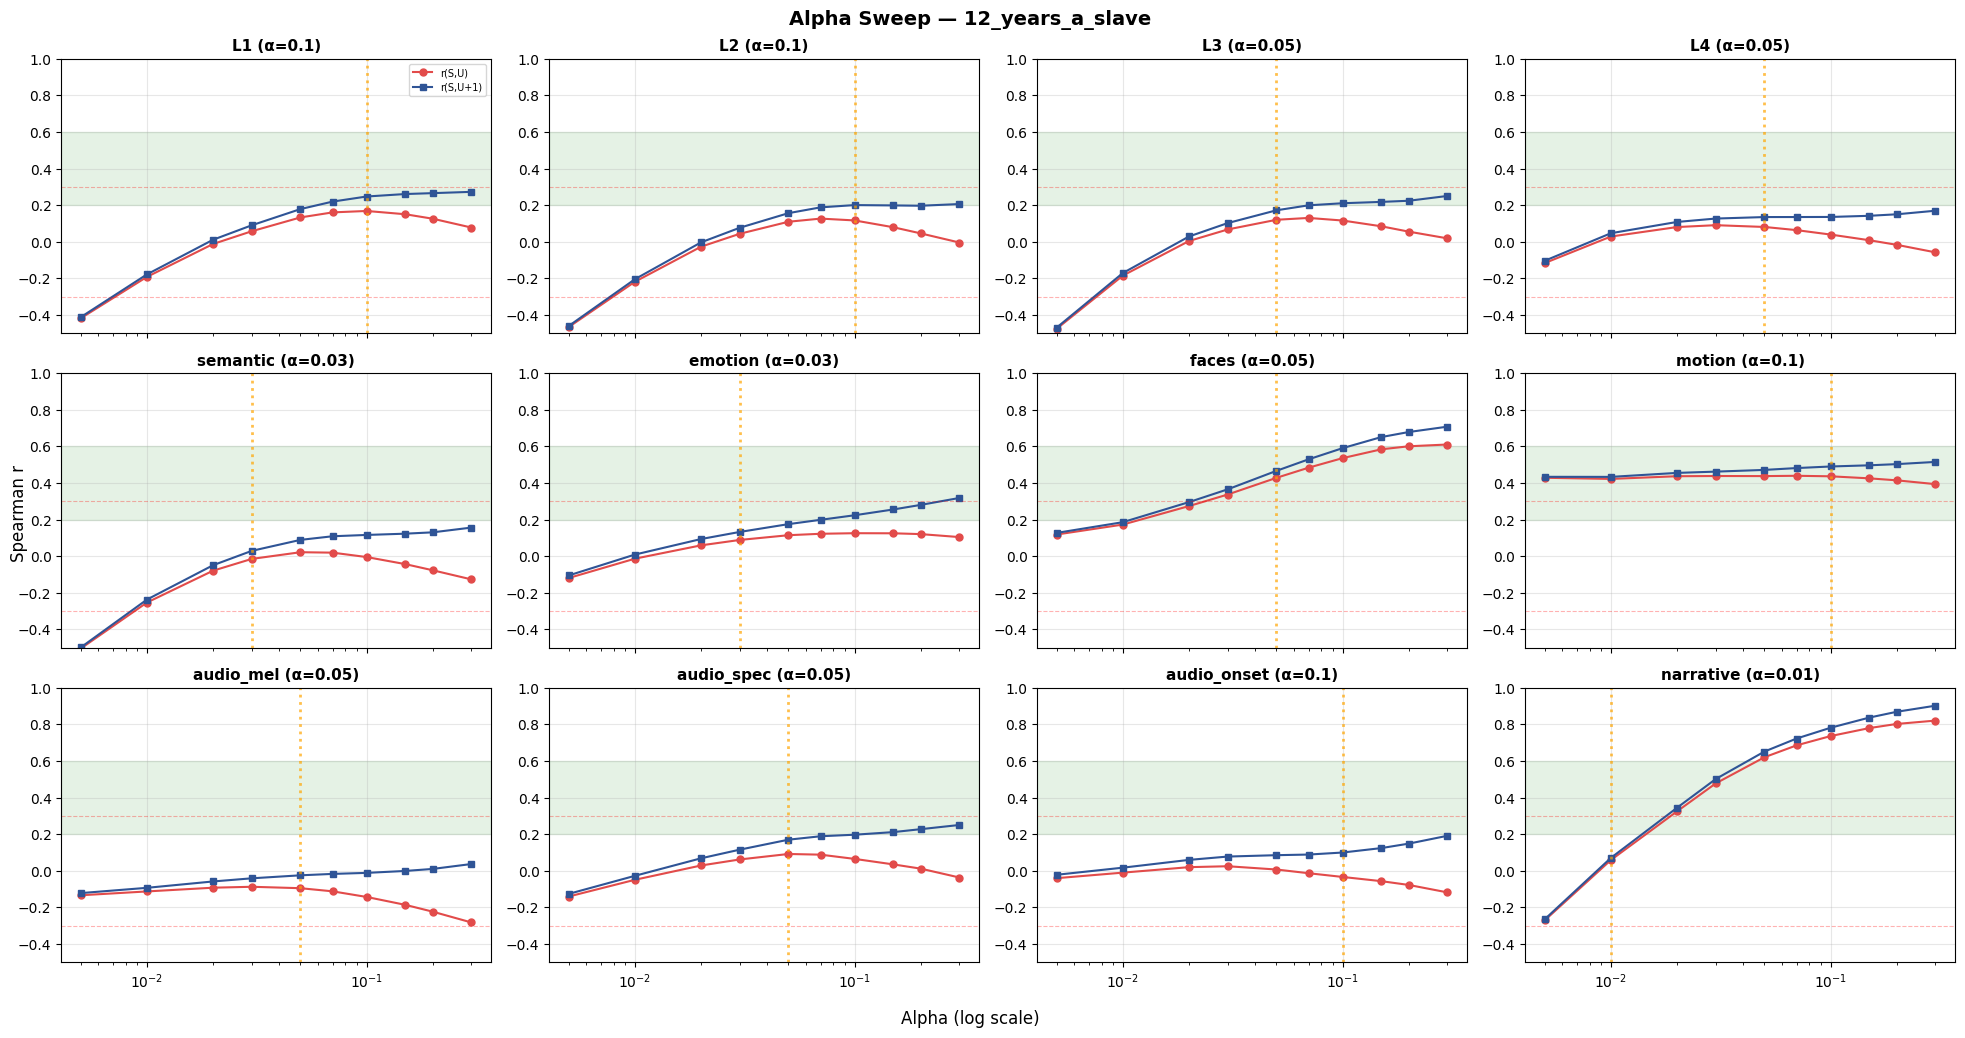

Saved: alpha_sweep.png


In [21]:
# Alpha sweep visualization
n_ch = len(sweep_results)
n_rows = (n_ch + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(20, 3.5 * n_rows), sharex=True)
axes = axes.ravel()

for idx, (ch, ch_results) in enumerate(sweep_results.items()):
    if idx >= len(axes): break
    ax = axes[idx]
    alphas = [r[0] for r in ch_results]
    r_c = [r[1] for r in ch_results]
    r_l = [r[2] for r in ch_results]
    ax.plot(alphas, r_c, 'o-', color='#E24B4A', label='r(S,U)', ms=5)
    ax.plot(alphas, r_l, 's-', color='#2F5496', label='r(S,U+1)', ms=5)
    ax.axhspan(0.2, 0.6, alpha=0.1, color='green')
    ax.axhline(0.3, color='red', ls='--', alpha=0.3, lw=0.8)
    ax.axhline(-0.3, color='red', ls='--', alpha=0.3, lw=0.8)
    cur = ALPHA.get(ch)
    if cur: ax.axvline(cur, color='orange', ls=':', alpha=0.7, lw=2)
    ax.set_title(f"{ch} (α={cur})", fontsize=11, fontweight='bold')
    ax.set_ylim(-0.5, 1.0)
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    if idx == 0: ax.legend(fontsize=7)

for idx in range(len(sweep_results), len(axes)): axes[idx].set_visible(False)
fig.supxlabel('Alpha (log scale)')
fig.supylabel('Spearman r')
fig.suptitle(f'Alpha Sweep — {sweep_film}', fontsize=14, fontweight='bold')
plt.tight_layout()
#plt.savefig('alpha_sweep.png', dpi=150, bbox_inches='tight')
#print("Saved: alpha_sweep.png")
plt.show()


In [22]:
# Suggest optimal alpha with hierarchical constraint
print("Suggested alphas (dynamics-optimal + hierarchical constraint):")
print(f"{'Channel':<15} {'Group':>5} {'Current':>8} {'Optimal':>8} {'r(S,U)':>8} {'r(S,U+1)':>9} {'Change'}")
print("-" * 75)

suggested = {}
for ch, ch_results in sweep_results.items():
    current = ALPHA.get(ch, 0.05)
    group = HIERARCHY.get(ch, 2)
    best_alpha, best_score = current, float('inf')
    best_rc, best_rl = np.nan, np.nan
    for alpha, r_c, r_l in ch_results:
        if np.isnan(r_c): continue
        cp = max(0, abs(r_c) - 0.3) * 10
        lp = max(0, 0.2 - r_l) * 10 if r_l < 0.2 else (max(0, r_l - 0.6) * 5 if r_l > 0.6 else 0)
        score = cp + lp + abs(r_c)
        if score < best_score:
            best_score, best_alpha, best_rc, best_rl = score, alpha, r_c, r_l
    suggested[ch] = {'alpha': best_alpha, 'group': group, 'r_c': best_rc, 'r_l': best_rl}

# Apply hierarchical constraint: slower groups can't have higher alpha than faster groups
group_max = {}
for g in sorted(set(HIERARCHY.values())):
    chs_in_group = [ch for ch, gr in HIERARCHY.items() if gr == g and ch in suggested]
    if chs_in_group:
        group_max[g] = max(suggested[ch]['alpha'] for ch in chs_in_group)

for ch in suggested:
    g = suggested[ch]['group']
    # Check: no slower group should have alpha > any faster group's max
    for faster_g in range(1, g):
        if faster_g in group_max and suggested[ch]['alpha'] > group_max[faster_g]:
            suggested[ch]['alpha'] = group_max[faster_g]
            suggested[ch]['constrained'] = True

for ch in sweep_results:
    s = suggested[ch]
    current = ALPHA.get(ch, 0.05)
    change = f"{current}→{s['alpha']}" if s['alpha'] != current else "no change"
    constrained = " [H]" if s.get('constrained') else ""
    print(f"  {ch:<15} {s['group']:>5} {current:>8.3f} {s['alpha']:>8.3f} {s['r_c']:>+8.3f} {s['r_l']:>+9.3f} {change}{constrained}")

print()
print("[H] = constrained by hierarchy (slower group can't exceed faster group's alpha)")
print()
print("Hierarchy groups:")
for g in sorted(set(HIERARCHY.values())):
    members = [ch for ch, gr in HIERARCHY.items() if gr == g]
    print(f"  Group {g}: {members}")

Suggested alphas (dynamics-optimal + hierarchical constraint):
Channel         Group  Current  Optimal   r(S,U)  r(S,U+1) Change
---------------------------------------------------------------------------
  L1                  1    0.100    0.300   +0.077    +0.273 0.1→0.3
  L2                  1    0.100    0.300   -0.005    +0.206 0.1→0.3
  L3                  2    0.050    0.300   +0.018    +0.250 0.05→0.3
  L4                  2    0.050    0.300   -0.058    +0.169 0.05→0.3
  semantic            3    0.030    0.300   -0.127    +0.157 0.03→0.3
  emotion             3    0.030    0.300   +0.105    +0.319 0.03→0.3
  faces               2    0.050    0.020   +0.274    +0.296 0.05→0.02
  motion              1    0.100    0.300   +0.394    +0.516 0.1→0.3
  audio_mel           2    0.050    0.300   -0.283    +0.037 0.05→0.3
  audio_spec          2    0.050    0.200   +0.011    +0.227 0.05→0.2
  audio_onset         1    0.100    0.300   -0.118    +0.191 0.1→0.3
  narrative           4    0

---
# 4. Cross-Film Alpha Validation

Cross-film sweep (10 films)


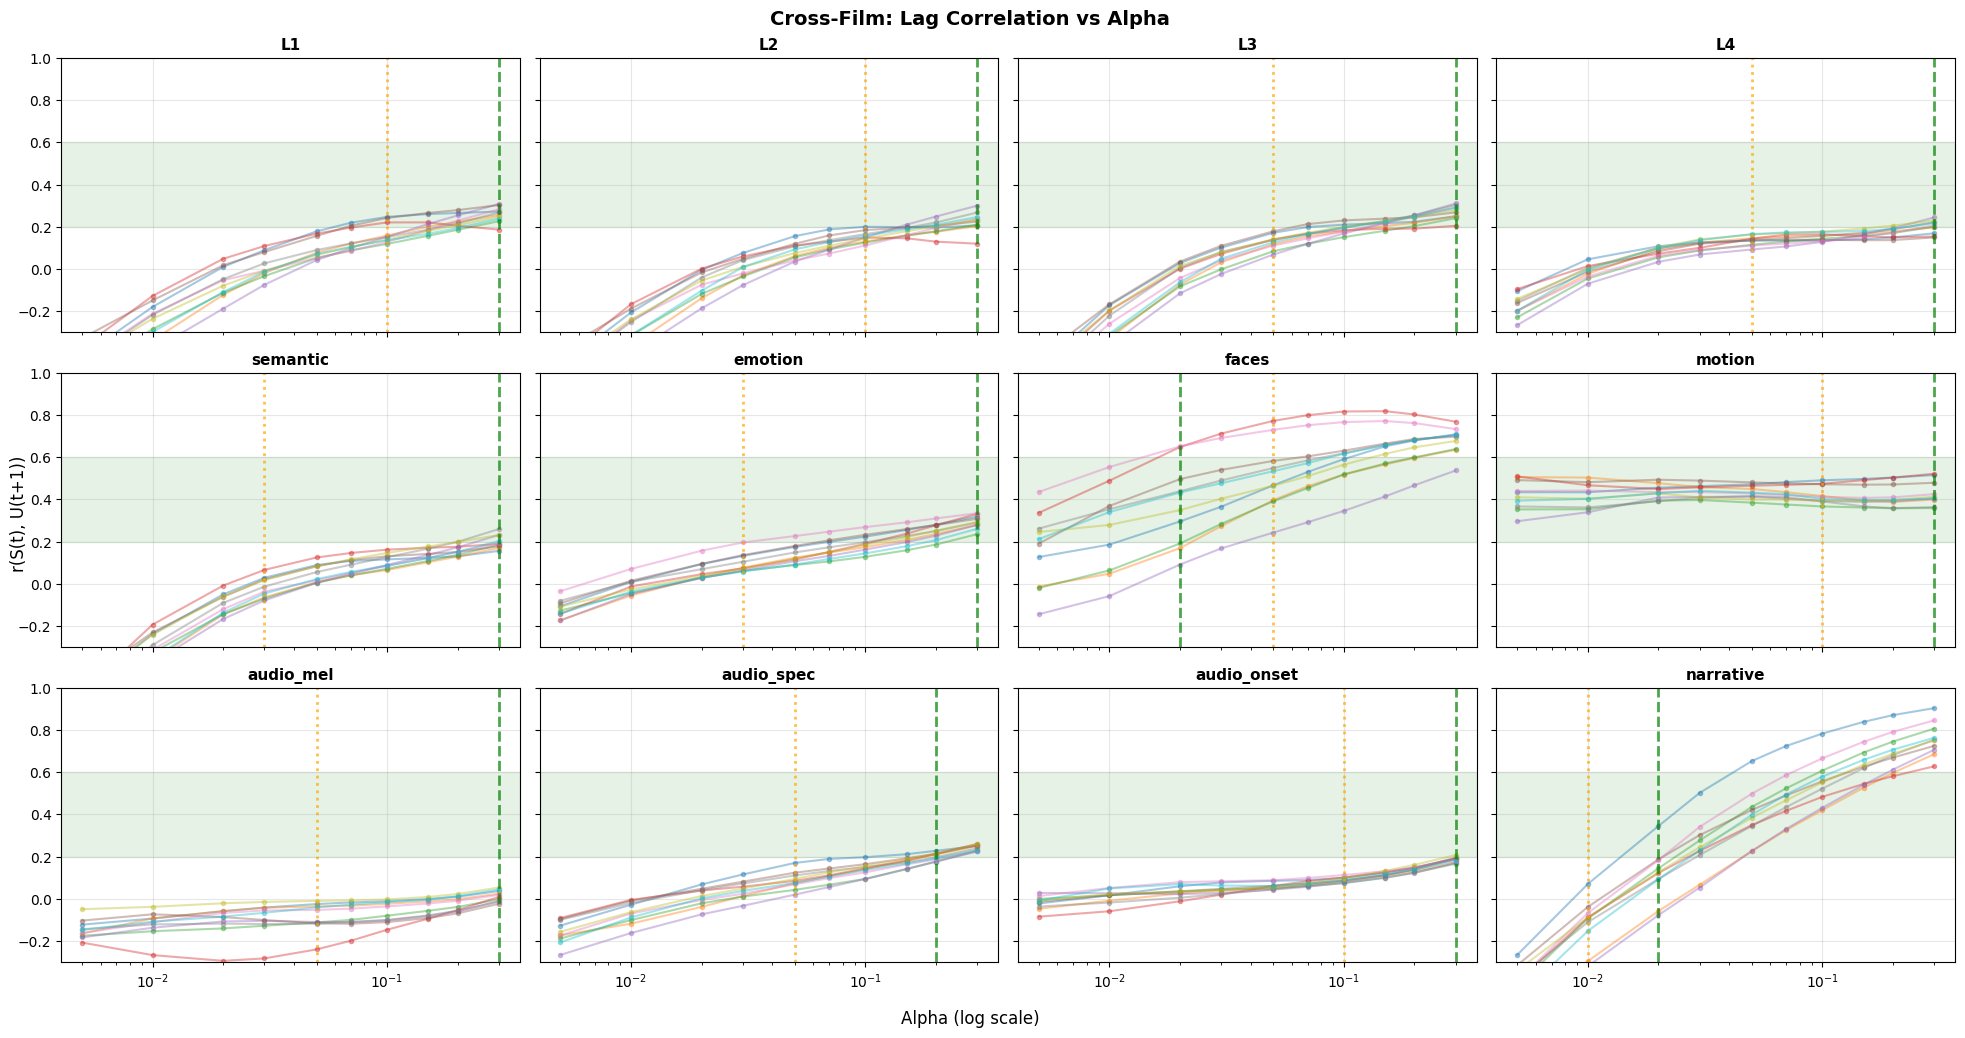

Orange=current, Green dashed=suggested. Green band=healthy zone.
Tight clustering → robust. Spread → film-dependent.


In [35]:
if len(films) > 1:
    print(f"Cross-film sweep ({len(films)} films)")
    cross = {ch: [] for ch in sweep_results}
    
    for fn, data in films.items():
        df2_cf = data["df2"]
        offset = 0
        for ch in cfg.FEATURE_CHANNEL_ORDER:
            d = cfg.FEATURE_DIMS[ch]
            if ch not in cross:
                offset += d
                continue
            feats = df2_cf.iloc[:, offset:offset+d].values
            if feats.std() < 1e-9:
                offset += d
                continue
            fr = []
            for alpha in alphas_to_test:
                s, u = run_ema_with_alpha(feats, alpha)
                r_c, r_l = compute_su_correlations(s, u)
                fr.append((alpha, r_c, r_l))
            cross[ch].append((fn, fr))
            offset += d
    
    n_ch = len(cross)
    n_rows = (n_ch + 3) // 4
    fig, axes = plt.subplots(n_rows, 4, figsize=(20, 3.5 * n_rows), sharex=True, sharey=True)
    axes = axes.ravel()
    for idx, (ch, film_data) in enumerate(cross.items()):
        if idx >= len(axes): break
        ax = axes[idx]
        for fn, fr in film_data:
            ax.plot([r[0] for r in fr], [r[2] for r in fr], 'o-', alpha=0.4, ms=3, label=fn[:12])
        ax.axhspan(0.2, 0.6, alpha=0.1, color='green')
        cur = ALPHA.get(ch)
        sug = suggested[ch]['alpha'] if ch in suggested else None
        if cur: ax.axvline(cur, color='orange', ls=':', alpha=0.7, lw=2)
        if sug and sug != cur: ax.axvline(sug, color='green', ls='--', alpha=0.7, lw=2)
        ax.set_title(f"{ch}", fontsize=11, fontweight='bold')
        ax.set_ylim(-0.3, 1.0)
        ax.set_xscale('log')
        ax.grid(True, alpha=0.3)
    for idx in range(len(cross), len(axes)): axes[idx].set_visible(False)
    fig.supxlabel('Alpha (log scale)')
    fig.supylabel('r(S(t), U(t+1))')
    fig.suptitle('Cross-Film: Lag Correlation vs Alpha', fontsize=14, fontweight='bold')
    plt.tight_layout()
    #plt.savefig('alpha_cross_film.png', dpi=150, bbox_inches='tight')
    #print("Saved: alpha_cross_film.png")
    plt.show()
    print("Orange=current, Green dashed=suggested. Green band=healthy zone.")
    print("Tight clustering → robust. Spread → film-dependent.")
else:
    print("Only 1 film. Load more for cross-film validation.")

---
# 5. Visualization

In [29]:
viz_film = list(films.keys())[0]
df1_v, df2_v = films[viz_film]["df1"], films[viz_film]["df2"]
T = len(df1_v)
t_min = np.arange(T) / 60.0
print(f"Visualizing: {viz_film} ({T}s = {T/60:.0f} min)")

Visualizing: 12_years_a_slave (7717s = 129 min)


## Full Film Overview

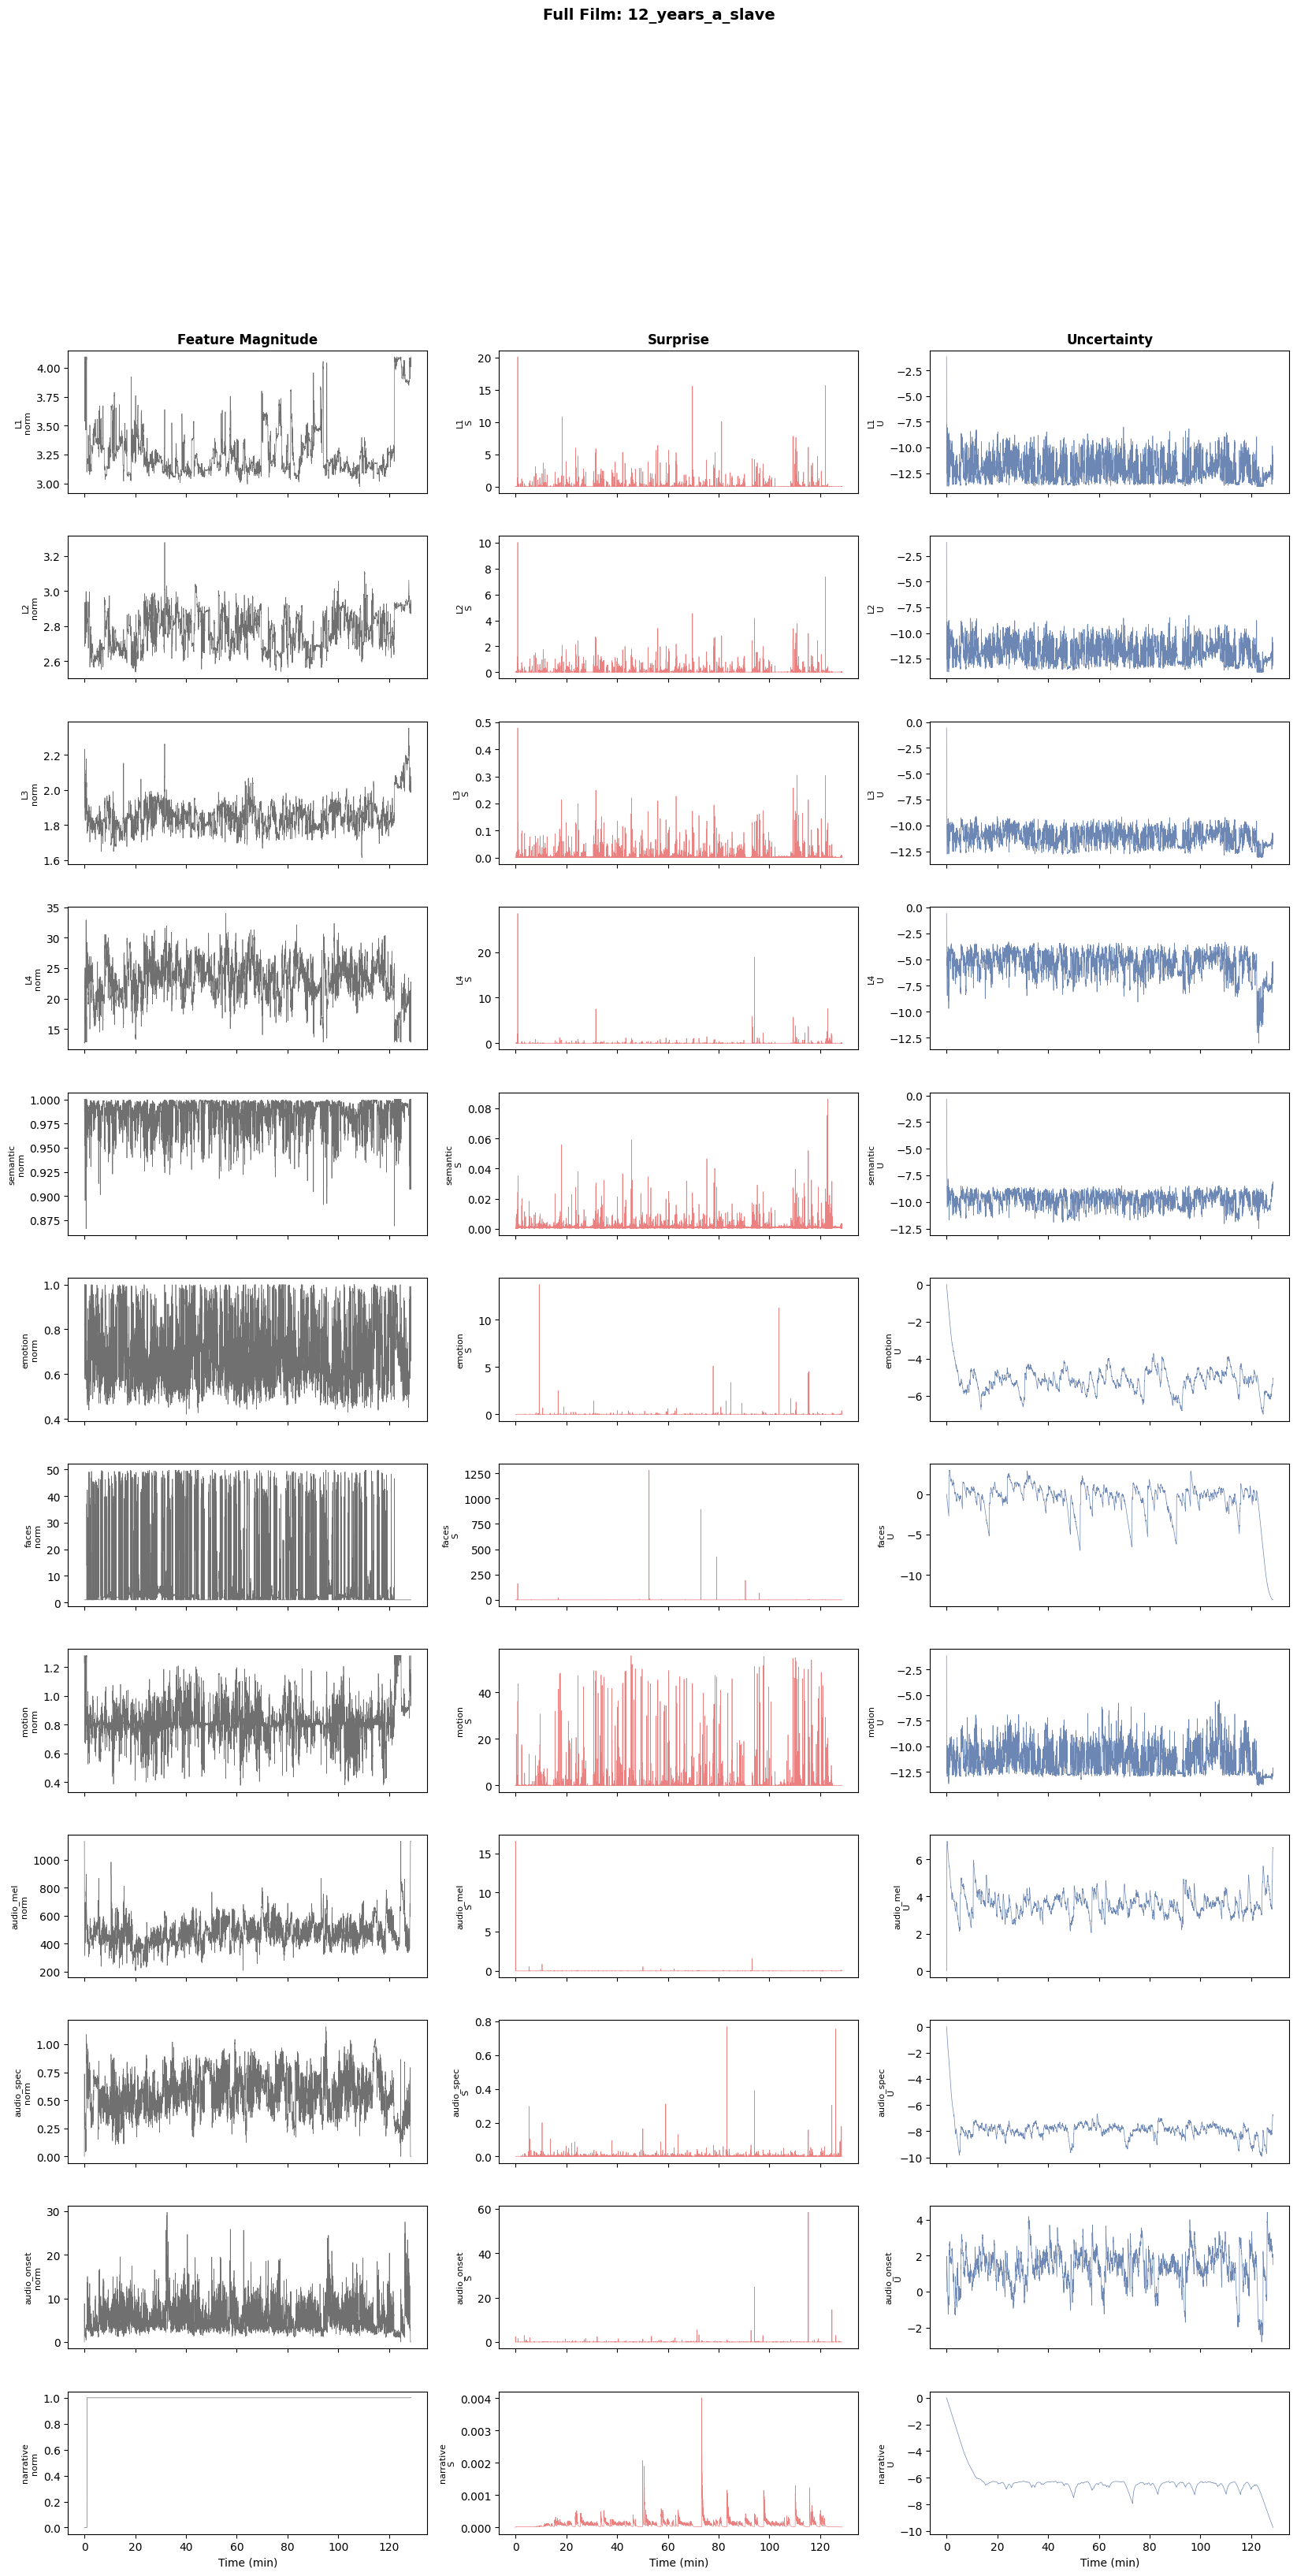

In [30]:
fig, axes = plt.subplots(len(CHANNELS), 3, figsize=(20, 3*len(CHANNELS)), sharex=True,
                         gridspec_kw={'hspace': 0.3})
offset = 0
for i, ch in enumerate(cfg.FEATURE_CHANNEL_ORDER):
    d = cfg.FEATURE_DIMS[ch]
    feats = df2_v.iloc[:, offset:offset+d].values
    axes[i,0].plot(t_min, np.linalg.norm(feats, axis=1), color='#333', lw=0.5, alpha=0.7)
    axes[i,0].set_ylabel(f'{ch}\nnorm', fontsize=8)
    if f'surprise_{ch}' in df1_v.columns:
        axes[i,1].plot(t_min, df1_v[f'surprise_{ch}'].values, color='#E24B4A', lw=0.5, alpha=0.7)
    axes[i,1].set_ylabel(f'{ch}\nS', fontsize=8)
    if f'uncertainty_{ch}' in df1_v.columns:
        axes[i,2].plot(t_min, df1_v[f'uncertainty_{ch}'].values, color='#2F5496', lw=0.5, alpha=0.7)
    axes[i,2].set_ylabel(f'{ch}\nU', fontsize=8)
    if i == 0:
        axes[i,0].set_title('Feature Magnitude', fontweight='bold')
        axes[i,1].set_title('Surprise', fontweight='bold')
        axes[i,2].set_title('Uncertainty', fontweight='bold')
    offset += d
for j in range(3): axes[-1,j].set_xlabel('Time (min)')
fig.suptitle(f'Full Film: {viz_film}', fontsize=14, fontweight='bold', y=1.001)
#plt.savefig('full_film_overview.png', dpi=100, bbox_inches='tight')
plt.show()

## Detailed Zoom (5 minutes, overlaid signals)

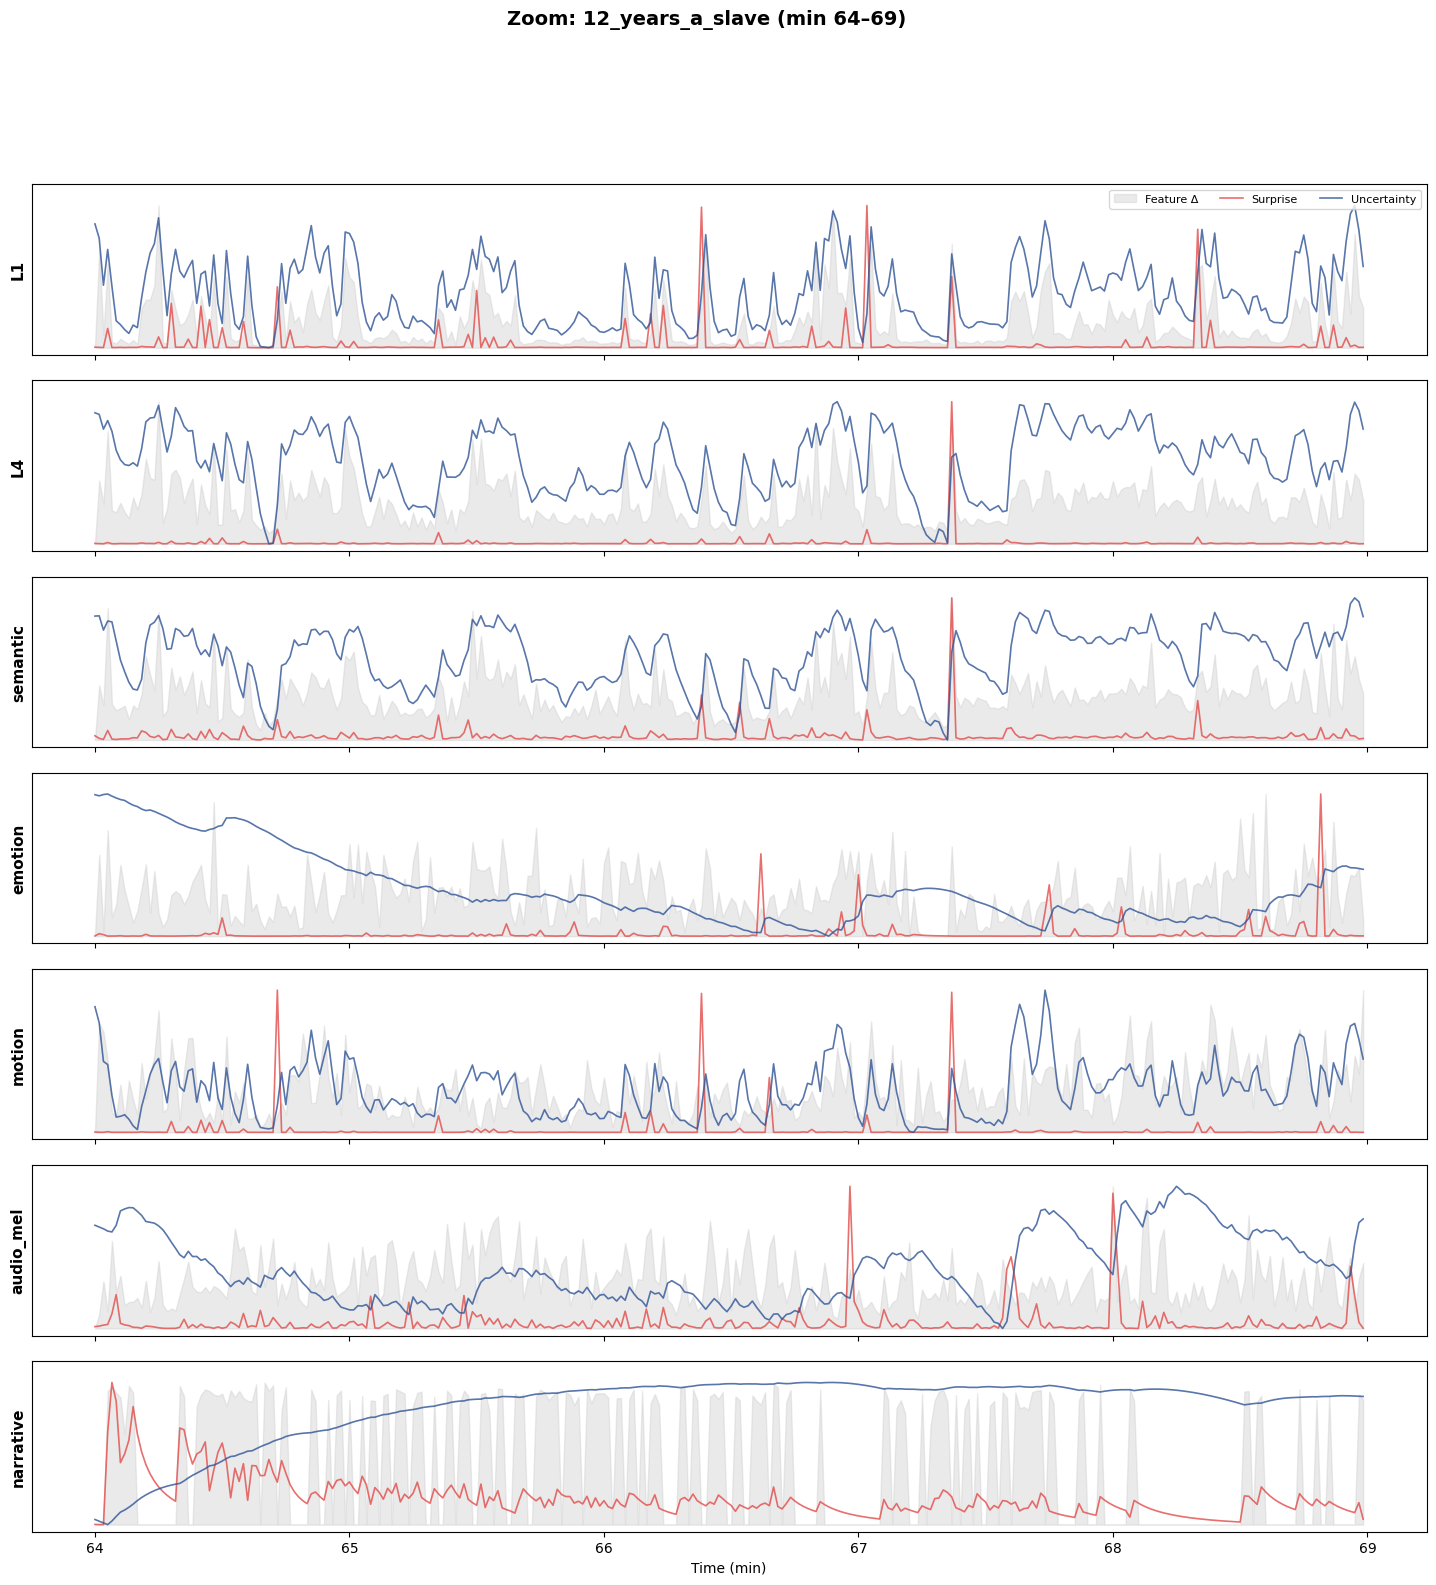

In [31]:
z_start = T // (2 * 60) * 60  # middle of film, rounded to minute
z_end = min(z_start + 300, T)
z_time = np.arange(z_start, z_end) / 60.0
zoom_chs = ['L1', 'L4', 'semantic', 'emotion', 'motion', 'audio_mel', 'narrative']

def norm01(x):
    x = np.nan_to_num(x, 0)
    r = x.max() - x.min()
    return (x - x.min()) / r if r > 1e-12 else np.zeros_like(x)

fig, axes = plt.subplots(len(zoom_chs), 1, figsize=(18, 2.5*len(zoom_chs)),
                         sharex=True, gridspec_kw={'hspace': 0.15})
for i, ch in enumerate(zoom_chs):
    ax = axes[i]
    offset = sum(cfg.FEATURE_DIMS[c] for c in cfg.FEATURE_CHANNEL_ORDER if c != ch
                 and list(cfg.FEATURE_CHANNEL_ORDER).index(c) < list(cfg.FEATURE_CHANNEL_ORDER).index(ch))
    # Recalculate offset properly
    offset = 0
    for c in cfg.FEATURE_CHANNEL_ORDER:
        if c == ch: break
        offset += cfg.FEATURE_DIMS[c]
    d = cfg.FEATURE_DIMS[ch]
    feats = df2_v.iloc[z_start:z_end, offset:offset+d].values
    delta = np.zeros(len(feats))
    delta[1:] = np.linalg.norm(np.diff(feats, axis=0), axis=1)
    ax.fill_between(z_time, 0, norm01(delta), color='#CCC', alpha=0.4, label='Feature Δ')
    if f'surprise_{ch}' in df1_v.columns:
        ax.plot(z_time, norm01(df1_v[f'surprise_{ch}'].values[z_start:z_end]),
                color='#E24B4A', lw=1.2, alpha=0.8, label='Surprise')
    if f'uncertainty_{ch}' in df1_v.columns:
        ax.plot(z_time, norm01(df1_v[f'uncertainty_{ch}'].values[z_start:z_end]),
                color='#2F5496', lw=1.2, alpha=0.8, label='Uncertainty')
    ax.set_ylabel(ch, fontsize=11, fontweight='bold')
    ax.set_ylim(-0.05, 1.15)
    ax.set_yticks([])
    if i == 0: ax.legend(loc='upper right', fontsize=8, ncol=3)
axes[-1].set_xlabel('Time (min)')
fig.suptitle(f'Zoom: {viz_film} (min {z_start//60}–{z_end//60})', fontsize=14, fontweight='bold')
#plt.savefig('zoom_view.png', dpi=150, bbox_inches='tight')
plt.show()

## S(t) vs U(t) and S(t) vs U(t+1) Scatter Plots

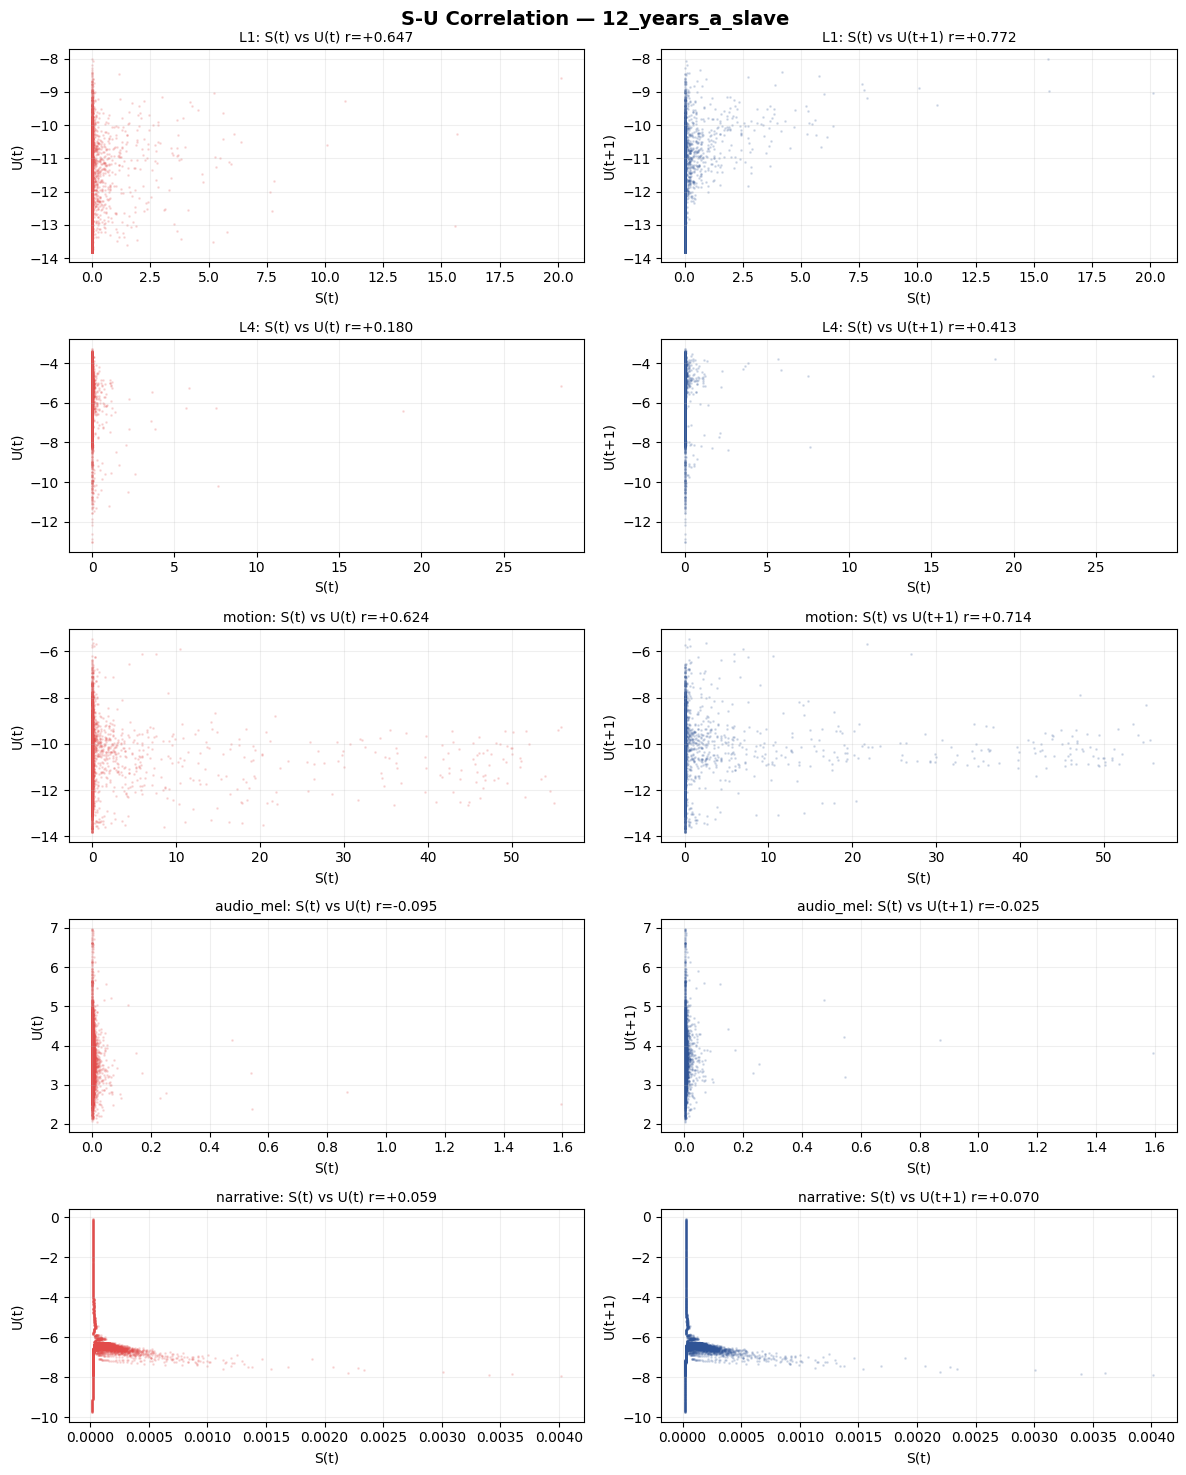

In [32]:
scatter_chs = ['L1', 'L4', 'motion', 'audio_mel', 'narrative']
fig, axes = plt.subplots(len(scatter_chs), 2, figsize=(12, 3*len(scatter_chs)))
for i, ch in enumerate(scatter_chs):
    s_col, u_col = f'surprise_{ch}', f'uncertainty_{ch}'
    if s_col not in df1_v.columns or df1_v[s_col].isna().all():
        axes[i,0].text(0.5, 0.5, f'{ch}: no data', transform=axes[i,0].transAxes, ha='center')
        continue
    s, u = df1_v[s_col].values[10:], df1_v[u_col].values[10:]
    valid = ~(np.isnan(s)|np.isnan(u))
    # Contemporaneous
    axes[i,0].scatter(s[valid], u[valid], s=1, alpha=0.15, color='#E24B4A')
    r_c = spearmanr(s[valid], u[valid])[0] if valid.sum()>30 else np.nan
    axes[i,0].set_title(f'{ch}: S(t) vs U(t) r={r_c:+.3f}', fontsize=10)
    axes[i,0].set_xlabel('S(t)'); axes[i,0].set_ylabel('U(t)')
    axes[i,0].grid(True, alpha=0.2)
    # Lagged
    axes[i,1].scatter(s[valid][:-1], u[valid][1:], s=1, alpha=0.15, color='#2F5496')
    r_l = spearmanr(s[valid][:-1], u[valid][1:])[0] if valid.sum()>30 else np.nan
    axes[i,1].set_title(f'{ch}: S(t) vs U(t+1) r={r_l:+.3f}', fontsize=10)
    axes[i,1].set_xlabel('S(t)'); axes[i,1].set_ylabel('U(t+1)')
    axes[i,1].grid(True, alpha=0.2)
fig.suptitle(f'S-U Correlation — {viz_film}', fontsize=14, fontweight='bold')
plt.tight_layout()
#plt.savefig('su_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary

In [33]:
print("=" * 60)
print("Phase 7 — Alpha Dynamics & Cross-Film Validation")
print("=" * 60)
print()
print("Outputs:")
print("  alpha_sweep.png       — per-channel dynamics")
print("  alpha_cross_film.png  — multi-film consistency")
print("  full_film_overview.png")
print("  zoom_view.png")
print("  su_scatter.png")
print()
print("Next steps:")
print("  1. Review suggested alphas + hierarchical constraints")
print("  2. Decide which to adopt")
print("  3. If alphas change: update config.py, re-run pipeline")
print("  4. Re-run P-07, P-08, P-09 with new alphas")
print("  5. Proceed to Phase 8 (qualitative inspection)")

Phase 7 — Alpha Dynamics & Cross-Film Validation

Outputs:
  alpha_sweep.png       — per-channel dynamics
  alpha_cross_film.png  — multi-film consistency
  full_film_overview.png
  zoom_view.png
  su_scatter.png

Next steps:
  1. Review suggested alphas + hierarchical constraints
  2. Decide which to adopt
  3. If alphas change: update config.py, re-run pipeline
  4. Re-run P-07, P-08, P-09 with new alphas
  5. Proceed to Phase 8 (qualitative inspection)
